In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
import json
from pathlib import Path
import os, glob
import tqdm
from nilearn import maskers
import nilearn.signal

In [2]:
BOLD_ROOT = "/srv/nfs-data/sisko/storage/kamitani_sound/ds006319_derivatives_fmriprep"
RAW_ROOT  = "/srv/nfs-data/sisko/storage/kamitani_sound/ds006319" 
WAV_ROOT  = "/srv/nfs-data/sisko/storage/kamitani_sound/vggsound_wav"
subj = "sub-S1"   # cambia qui
TR = 2.0         # in secondi

# tutte le run di quel soggetto
func_glob = os.path.join(BOLD_ROOT, subj, "ses-*", "func", "*_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz")
filenames = sorted(glob.glob(func_glob))
len(filenames), filenames[0]

(112,
 '/srv/nfs-data/sisko/storage/kamitani_sound/ds006319_derivatives_fmriprep/sub-S1/ses-SoundAttention01/func/sub-S1_ses-SoundAttention01_task-AADDichotic_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')

In [3]:
filenames = filenames[8:] 

In [4]:
def bold_to_events_path(bold_path, raw_root):
    base = os.path.basename(bold_path)
    parts = base.split("_")

    sub = parts[0]                      # sub-S1
    ses = [p for p in parts if p.startswith("ses-")][0]
    task = [p for p in parts if p.startswith("task-")][0]
    run  = [p for p in parts if p.startswith("run-")][0]

    events_name = f"{sub}_{ses}_{task}_{run}_events.tsv"
    return os.path.join(raw_root, sub, ses, "func", events_name)


In [5]:
pairs = []  # lista di dict: {bold_path, bold_img, events_path, events_df}

for fn in tqdm.tqdm(filenames):
    events_path = bold_to_events_path(fn, RAW_ROOT)
    if not os.path.exists(events_path):
        print("[WARN] events missing:", events_path)
        continue

    x = nib.load(fn)
    df = pd.read_csv(events_path, sep="\t")
    pairs.append({"bold_path": fn, "bold_img": x, "events_path": events_path, "events_df": df})

print("paired runs:", len(pairs))
print("events columns example:", pairs[0]["events_df"].columns.tolist())


100%|██████████| 104/104 [00:00<00:00, 226.27it/s]

paired runs: 104
events columns example: ['onset', 'duration', 'trial_type', 'stimulus_name', 'category_index', 'sound_index', 'response_time']


In [ ]:
pairs[0]

In [7]:
pairs[0]['bold_img'].shape

(77, 95, 82, 295)

In [8]:
masker = maskers.NiftiMasker(
    mask_strategy="epi",
)
masker.fit(pairs[0]['bold_img'])

NiftiMasker(mask_strategy='epi', memory=Memory(location=None))

In [9]:
mask = True  
data = []
if mask:
    for img_path, img in tqdm.tqdm(list(zip(filenames, [p['bold_img'] for p in pairs]))):
        data.append(masker.transform_single_imgs(img).T)

100%|██████████| 104/104 [13:58<00:00,  8.07s/it]


In [10]:
cleaned_data = [nilearn.signal.clean(d.T,detrend=True,standardize=True,t_r=TR) for d in tqdm.tqdm(data)]

  0%|          | 0/104 [00:00<?, ?it/s]/tmp/ipykernel_1394159/1589352339.py:1: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  cleaned_data = [nilearn.signal.clean(d.T,detrend=True,standardize=True,t_r=TR) for d in tqdm.tqdm(data)]
100%|██████████| 104/104 [04:15<00:00,  2.46s/it]


In [12]:
cleaned_data[1].shape, len(cleaned_data)

((295, 208144), 104)

In [13]:
STIM_CSV_PATH = "/home/matteoc/brainSounds/SoundReconstruction_stimulus.csv"  # <-- path corretto
stim_df = pd.read_csv(STIM_CSV_PATH)

id2label = dict(zip(stim_df["YouTube ID"].astype(str), stim_df["label"].astype(str)))

def extract_youtube_id(stim_name: str) -> str | None:
    """
    stim_name es: vggtest_<YOUTUBE_ID>_<start>_<end>
    dove <YOUTUBE_ID> può contenere '_' (trattini bassi).
    """
    if not isinstance(stim_name, str):
        return None
    if stim_name.startswith("vggtest_"):
        core = stim_name[len("vggtest_"):]
    elif stim_name.startswith("vggtrain_"):
        core = stim_name[len("vggtrain_"):]
    else:
        return None

    parts = core.split("_")
    if len(parts) < 3:
        return None

    # ultimi due sono start/end -> li togliamo
    ytid = "_".join(parts[:-2])
    return ytid if len(ytid) > 0 else None


## Mapping with avg repetitions

In [65]:
import os, glob
import numpy as np
import tqdm
import torchaudio
from collections import defaultdict

TR = 2.0
stimdur = 10.0

delay_sec = 4.0   # 2 TR
n_tp = 7
delay_trs = int(round(delay_sec / TR))

def is_attention_run(bold_path: str) -> bool:
    return "ses-SoundAttention" in bold_path

def is_test_run(bold_path: str) -> bool:
    return "ses-SoundTest" in bold_path

def is_training_run(bold_path: str) -> bool:
    return "ses-SoundTraining" in bold_path

def find_wav_for_stimulus(stimulus_name: str, wav_root: str) -> str | None:
    if stimulus_name is None or (isinstance(stimulus_name, float) and np.isnan(stimulus_name)):
        return None
    p1 = os.path.join(wav_root, f"{stimulus_name}.wav")
    if os.path.exists(p1):
        return p1
    hits = glob.glob(os.path.join(wav_root, "**", f"{stimulus_name}*.wav"), recursive=True)
    return sorted(hits)[0] if len(hits) > 0 else None

# ---- NEW: accumulator dictionaries ----
# key -> list of fmri chunks (each: (n_tp, n_vox))
train_fmri_by_stim = defaultdict(list)
test_fmri_by_stim  = defaultdict(list)

# key -> single audio/sr/label/meta exemplar (store first one)
train_audio_by_stim = {}
test_audio_by_stim  = {}
train_label_by_stim = {}
test_label_by_stim  = {}
train_meta_by_stim  = defaultdict(list)  # keep all metas if you want
test_meta_by_stim   = defaultdict(list)

# cleaned_data deve essere allineata a pairs (stesso ordine).
assert len(cleaned_data) == len(pairs), "cleaned_data e pairs non hanno stessa lunghezza: riallinea prima."

for run_data, pr in tqdm.tqdm(list(zip(cleaned_data, pairs)), desc="Runs"):
    bold_path = pr["bold_path"]
    if is_attention_run(bold_path):
        continue

    df = pr["events_df"].copy()

    if "stimulus_name" not in df.columns:
        raise ValueError(f"events_df non ha stimulus_name in {pr['events_path']}")

    df = df[df["stimulus_name"].notna()]
    if "duration" in df.columns:
        df = df[df["duration"] > 0]

    T = run_data.shape[0]

    for i in range(len(df)):
        onset = float(df.iloc[i]["onset"])
        stim_name = str(df.iloc[i]["stimulus_name"])

        onset_tr = int(np.floor(onset / TR))
        start_tr = onset_tr + delay_trs
        end_tr = start_tr + n_tp
        if start_tr < 0 or end_tr > T:
            continue

        fmri_chunk = run_data[start_tr:end_tr]  # (n_tp, n_vox)

        wav_path = find_wav_for_stimulus(stim_name, WAV_ROOT)
        if wav_path is None:
            continue

        ytid = extract_youtube_id(stim_name)
        textual_label = id2label.get(ytid, "unknown")

        meta = {
            "bold_path": bold_path,
            "events_path": pr["events_path"],
            "row_idx": int(i),
            "onset_sec": onset,
            "start_tr": int(start_tr),
            "end_tr": int(end_tr),
            "stimulus_name": stim_name,
            "ytid": ytid,
        }

        # choose grouping key:
        # - use stim_name if you want different start/end treated as different stimuli
        # - use ytid if you want to merge across segments from same YouTube ID (attenzione: potrebbe essere diverso contenuto temporale!)
        key = stim_name

        if is_test_run(bold_path):
            test_fmri_by_stim[key].append(fmri_chunk)
            test_meta_by_stim[key].append(meta)
            if key not in test_audio_by_stim:
                try:
                    audio, sr = torchaudio.load(wav_path)
                except Exception:
                    continue
                test_audio_by_stim[key] = audio
                test_label_by_stim[key] = textual_label

        elif is_training_run(bold_path):
            train_fmri_by_stim[key].append(fmri_chunk)
            train_meta_by_stim[key].append(meta)
            if key not in train_audio_by_stim:
                try:
                    audio, sr = torchaudio.load(wav_path)
                except Exception:
                    continue
                train_audio_by_stim[key] = audio
                train_label_by_stim[key] = textual_label

# ---- Reduce: average across repetitions ----
def average_chunks(fmri_list):
    # fmri_list: list of (n_tp, n_vox)
    X = np.stack(fmri_list, axis=0)      # (n_rep, n_tp, n_vox)
    return X.mean(axis=0)                # (n_tp, n_vox)

train_keys_all = set(train_fmri_by_stim.keys())
train_keys_audio = set(train_audio_by_stim.keys())
train_keys_label = set(train_label_by_stim.keys())

train_keys = sorted(train_keys_all & train_keys_audio & train_keys_label)

test_keys = sorted(
    set(test_fmri_by_stim.keys()) &
    set(test_audio_by_stim.keys()) &
    set(test_label_by_stim.keys())
)

train_fmri    = [average_chunks(train_fmri_by_stim[k]) for k in train_keys]
train_audio   = [train_audio_by_stim[k] for k in train_keys]
train_textual = [train_label_by_stim[k] for k in train_keys]
train_stimname = train_keys

test_fmri    = [average_chunks(test_fmri_by_stim[k]) for k in test_keys]
test_audio   = [test_audio_by_stim[k] for k in test_keys]
test_textual = [test_label_by_stim[k] for k in test_keys]
test_stimname = test_keys

print("Train unique stimuli:", len(train_fmri))
print("Test unique stimuli:", len(test_fmri))
print("Example train fmri chunk shape:", train_fmri[0].shape)


Runs: 100%|██████████| 104/104 [00:11<00:00,  9.43it/s]


Train unique stimuli: 957
Test unique stimuli: 43
Example train fmri chunk shape: (7, 208144)


In [66]:
print("Train samples:", len(train_fmri), "Test samples:", len(test_fmri), 
      "Train textual labels:", len(train_textual), "Test textual labels:", len(test_textual), 
      "Train audio:", len(train_audio), "Test audio:", len(test_audio),
      )
print("Example fMRI chunk shape:", train_fmri[0].shape if len(train_fmri) else None)
print("Example audio shape:", train_audio[0].shape if len(train_audio) else None)

Train samples: 957 Test samples: 43 Train textual labels: 957 Test textual labels: 43 Train audio: 957 Test audio: 43
Example fMRI chunk shape: (7, 208144)
Example audio shape: torch.Size([2, 441923])


## Mapping with partial avg repetitions

In [64]:
import os, glob
import numpy as np
import tqdm
import torchaudio
from collections import defaultdict

TR = 2.0
stimdur = 10.0

delay_sec = 4.0   # 2 TR
n_tp = 7
delay_trs = int(round(delay_sec / TR))

# media solo se uno stimolo è ripetuto almeno R volte
R = 3

def is_attention_run(bold_path: str) -> bool:
    return "ses-SoundAttention" in bold_path

def is_test_run(bold_path: str) -> bool:
    return "ses-SoundTest" in bold_path

def is_training_run(bold_path: str) -> bool:
    return "ses-SoundTraining" in bold_path

def find_wav_for_stimulus(stimulus_name: str, wav_root: str) -> str | None:
    if stimulus_name is None or (isinstance(stimulus_name, float) and np.isnan(stimulus_name)):
        return None
    p1 = os.path.join(wav_root, f"{stimulus_name}.wav")
    if os.path.exists(p1):
        return p1
    hits = glob.glob(os.path.join(wav_root, "**", f"{stimulus_name}*.wav"), recursive=True)
    return sorted(hits)[0] if len(hits) > 0 else None

# ---- accumulator dictionaries ----
# key -> list of fmri chunks (each: (n_tp, n_vox))
train_fmri_by_stim = defaultdict(list)
test_fmri_by_stim  = defaultdict(list)

# key -> single audio + label exemplar (store first one that loads correctly)
train_audio_by_stim = {}
test_audio_by_stim  = {}
train_label_by_stim = {}
test_label_by_stim  = {}
train_meta_by_stim  = defaultdict(list)
test_meta_by_stim   = defaultdict(list)

# cleaned_data deve essere allineata a pairs (stesso ordine).
assert len(cleaned_data) == len(pairs), "cleaned_data e pairs non hanno stessa lunghezza: riallinea prima."

for run_data, pr in tqdm.tqdm(list(zip(cleaned_data, pairs)), desc="Runs"):
    bold_path = pr["bold_path"]
    if is_attention_run(bold_path):
        continue

    df = pr["events_df"].copy()
    if "stimulus_name" not in df.columns:
        raise ValueError(f"events_df non ha stimulus_name in {pr['events_path']}")

    df = df[df["stimulus_name"].notna()]
    if "duration" in df.columns:
        df = df[df["duration"] > 0]

    T = run_data.shape[0]

    for i in range(len(df)):
        onset = float(df.iloc[i]["onset"])
        stim_name = str(df.iloc[i]["stimulus_name"])

        onset_tr = int(np.floor(onset / TR))
        start_tr = onset_tr + delay_trs
        end_tr = start_tr + n_tp
        if start_tr < 0 or end_tr > T:
            continue

        fmri_chunk = run_data[start_tr:end_tr]  # (n_tp, n_vox)

        wav_path = find_wav_for_stimulus(stim_name, WAV_ROOT)
        if wav_path is None:
            continue

        ytid = extract_youtube_id(stim_name)
        textual_label = id2label.get(ytid, "unknown")

        meta = {
            "bold_path": bold_path,
            "events_path": pr["events_path"],
            "row_idx": int(i),
            "onset_sec": onset,
            "start_tr": int(start_tr),
            "end_tr": int(end_tr),
            "stimulus_name": stim_name,
            "ytid": ytid,
        }

        # grouping key (consigliato: stim_name)
        key = stim_name

        if is_test_run(bold_path):
            test_fmri_by_stim[key].append(fmri_chunk)
            test_meta_by_stim[key].append(meta)

            # salva audio/label solo la prima volta, ma SOLO se torchaudio.load va a buon fine
            if key not in test_audio_by_stim:
                try:
                    audio, sr = torchaudio.load(wav_path)
                    test_audio_by_stim[key] = audio
                    test_label_by_stim[key] = textual_label
                except Exception:
                    # se fallisce, non salviamo l'audio; lo stimolo verrà filtrato dopo (intersection keys)
                    pass

        elif is_training_run(bold_path):
            train_fmri_by_stim[key].append(fmri_chunk)
            train_meta_by_stim[key].append(meta)

            if key not in train_audio_by_stim:
                try:
                    audio, sr = torchaudio.load(wav_path)
                    train_audio_by_stim[key] = audio
                    train_label_by_stim[key] = textual_label
                except Exception:
                    pass

def groupwise_average(chunks, K=2, shuffle=True, seed=0):
    idx = np.arange(len(chunks))
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)
    out = []
    for start in range(0, len(idx), K):
        g = idx[start:start+K]
        X = np.stack([chunks[j] for j in g], axis=0)
        out.append(X.mean(axis=0))
    return out

K = 2  # prova 2 (più sample) o 3 (più SNR)

train_fmri, train_audio, train_textual, train_stimname = [], [], [], []
test_fmri,  test_audio,  test_textual,  test_stimname  = [], [], [], []

train_keys = sorted(set(train_fmri_by_stim) & set(train_audio_by_stim) & set(train_label_by_stim))
test_keys  = sorted(set(test_fmri_by_stim)  & set(test_audio_by_stim)  & set(test_label_by_stim))

# TRAIN: più sample per stimolo
for k in tqdm.tqdm(train_keys):
    chunks = train_fmri_by_stim[k]
    fmri_samples = groupwise_average(chunks, K=K, shuffle=True, seed=0)
    for fm in fmri_samples:
        train_fmri.append(fm)
        train_audio.append(train_audio_by_stim[k])
        train_textual.append(train_label_by_stim[k])
        train_stimname.append(k)

# TEST: di solito meglio 1 sample per stimolo (media totale) per stabilità
for k in tqdm.tqdm(test_keys):
    chunks = test_fmri_by_stim[k]
    fm = np.stack(chunks, axis=0).mean(axis=0)
    test_fmri.append(fm)
    test_audio.append(test_audio_by_stim[k])
    test_textual.append(test_label_by_stim[k])
    test_stimname.append(k)

print("Train samples:", len(train_fmri), "Train unique stimuli:", len(train_keys))
print("Test samples:", len(test_fmri), "Test unique stimuli:", len(test_keys))

print("Train samples:", len(train_fmri),
      "Train audio:", len(train_audio),
      "Train textual labels:", len(train_textual))
print("Test samples:", len(test_fmri),
      "Test audio:", len(test_audio),
      "Test textual labels:", len(test_textual))

print("Example fMRI chunk shape:", train_fmri[0].shape)
print("Example audio shape:", train_audio[0].shape)



100%|██████████| 43/43 [00:00<00:00, 168.44it/s]

Train samples: 2244 Train unique stimuli: 957
Test samples: 43 Test unique stimuli: 43
Train samples: 2244 Train audio: 2244 Train textual labels: 2244
Test samples: 43 Test audio: 43 Test textual labels: 43
Example fMRI chunk shape: (7, 208144)
Example audio shape: torch.Size([2, 441923])


## Feature Extraction

In [22]:
from transformers import ClapAudioModelWithProjection, ClapProcessor, AutoTokenizer, ClapTextModelWithProjection, ClapModel

device = "cuda:4"  
clap_text = ClapTextModelWithProjection.from_pretrained("laion/clap-htsat-fused").to(device)
clap_audio = ClapAudioModelWithProjection.from_pretrained("laion/clap-htsat-fused").to(device)
processor = ClapProcessor.from_pretrained("laion/clap-htsat-fused")
tokenizer = AutoTokenizer.from_pretrained("laion/clap-htsat-fused")

model = ClapModel.from_pretrained("laion/clap-htsat-fused").to(device)

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [67]:
import torch

train_audio_feat=[]
test_audio_feat=[]

train_textual_feat=[]
test_textual_feat=[]

# new_freq = 16000
# resampler = torchaudio.transforms.Resample(orig_freq=48000, new_freq=new_freq)

with torch.no_grad():
    for wv,txt in tqdm.tqdm(zip(train_audio,train_textual)):

        wv = wv.mean(dim=0, keepdim=True)
        inputs_audio = processor(audios=wv.squeeze(), return_tensors="pt", sampling_rate=48_000)
        inputs_audio = {k: v.to(device) for k, v in inputs_audio.items()}
        audio_features = clap_audio(**inputs_audio)
        train_audio_feat.append(audio_features.audio_embeds.cpu())
        
        inputs_text = processor(
            text=txt,
            return_tensors="pt",
            padding=True
        )
        inputs_text = {k: v.to(device) for k, v in inputs_text.items()}
        text_features = clap_text(**inputs_text)
        train_textual_feat.append(text_features.text_embeds.cpu())

with torch.no_grad():
    for wv,txt in tqdm.tqdm(zip(test_audio,test_textual)):

        wv = wv.mean(dim=0, keepdim=True)
        inputs_audio = processor(audios=wv.squeeze(), return_tensors="pt", sampling_rate=48_000)
        inputs_audio = {k: v.to(device) for k, v in inputs_audio.items()}
        audio_features = clap_audio(**inputs_audio)
        test_audio_feat.append(audio_features.audio_embeds.cpu())

        inputs_text = processor(
            text=txt,
            return_tensors="pt",
            padding=True
        )
        inputs_text = {k: v.to(device) for k, v in inputs_text.items()}
        text_features = clap_text(**inputs_text)
        test_textual_feat.append(text_features.text_embeds.cpu())



957it [00:26, 36.07it/s]
43it [00:01, 36.61it/s]


In [ ]:
# import torch

# train_audio_feat=[]
# test_audio_feat=[]

# train_textual_feat=[]
# test_textual_feat=[]

# with torch.no_grad():
#     for wv, txt in tqdm.tqdm(zip(train_audio, train_textual), total=len(train_audio)):
#         wv = wv.mean(dim=0, keepdim=True)

#         # processor su CPU (numpy per audio), poi tensori su GPU
#         inputs_audio = processor(audios=wv.squeeze(), sampling_rate=48_000, return_tensors="pt")
#         inputs_text  = processor(text=txt, return_tensors="pt", padding=True)

#         inputs_audio = {k: v.to(device) for k, v in inputs_audio.items()}
#         inputs_text  = {k: v.to(device) for k, v in inputs_text.items()}

#         a = model.get_audio_features(**inputs_audio)  # [1,512]
#         t = model.get_text_features(**inputs_text)    # [1,512]

#         train_audio_feat.append(a.cpu())
#         train_textual_feat.append(t.cpu())


# with torch.no_grad():
#     for wv, txt in tqdm.tqdm(zip(test_audio,test_textual), total=len(test_audio)):
#         wv = wv.mean(dim=0, keepdim=True)

#         inputs_audio = processor(audios=wv.squeeze(), sampling_rate=48_000, return_tensors="pt")
#         inputs_text  = processor(text=txt, return_tensors="pt", padding=True)

#         inputs_audio = {k: v.to(device) for k, v in inputs_audio.items()}
#         inputs_text  = {k: v.to(device) for k, v in inputs_text.items()}

#         a = model.get_audio_features(**inputs_audio)  # [1,512]
#         t = model.get_text_features(**inputs_text)    # [1,512]

#         test_audio_feat.append(a.cpu())
#         test_textual_feat.append(t.cpu())

In [68]:
train_audio_feat = torch.stack(train_audio_feat).squeeze()
test_audio_feat = torch.stack(test_audio_feat).squeeze()
train_textual_feat = torch.stack(train_textual_feat).squeeze()
test_textual_feat = torch.stack(test_textual_feat).squeeze()

In [69]:
train_audio_feat.shape, test_audio_feat.shape, train_textual_feat.shape, test_textual_feat.shape

(torch.Size([957, 512]),
 torch.Size([43, 512]),
 torch.Size([957, 512]),
 torch.Size([43, 512]))

In [70]:
train_fmri_avg=[]
test_fmri_avg=[]
for f in tqdm.tqdm(train_fmri):
    train_fmri_avg.append(f.mean(0))
for f in tqdm.tqdm(test_fmri):
    test_fmri_avg.append(f.mean(0))
train_fmri_avg=np.array(train_fmri_avg)
test_fmri_avg=np.array(test_fmri_avg)

100%|██████████| 43/43 [00:00<00:00, 2067.34it/s]


In [71]:
train_fmri_avg.shape, test_fmri_avg.shape

((957, 208144), (43, 208144))

## Encoding Model

/tmp/ipykernel_1394159/1439376526.py:28: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  R2_img_smooth_thr=nilearn.image.threshold_img(R2_img_smooth,threshold=thr,cluster_threshold=100)


Tot voxel selected:  2689


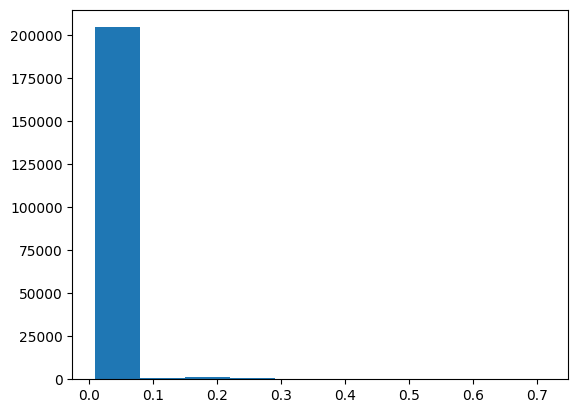

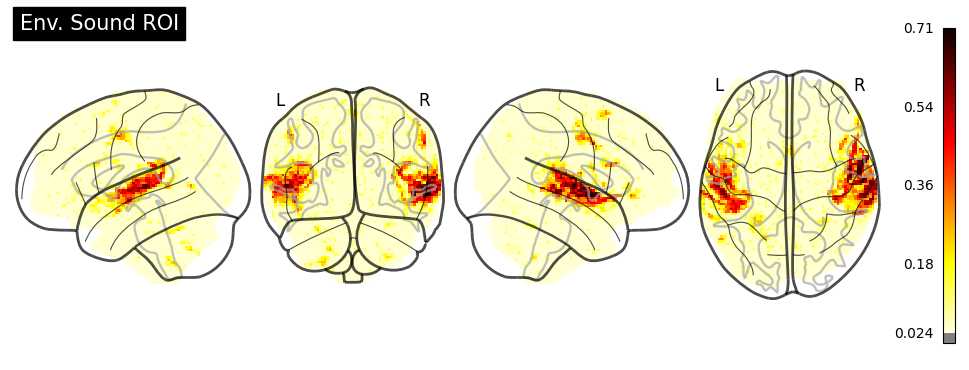

In [72]:
from joblib import dump
import matplotlib.pyplot as plt
import nilearn
from nilearn import plotting

train_encode_model=True
thr=0.10   

if train_encode_model:

    from himalaya.ridge import RidgeCV, Ridge
    from himalaya.kernel_ridge import KernelRidgeCV

    X=train_audio_feat.numpy()
    y=train_fmri_avg
    
    vm=RidgeCV(alphas=[0.01,0.1,1,10,20,50,1e2,1e3])
    # vm=RidgeCV(alphas=[20])
    # vm=Ridge()
    vm.fit(X,y)
    voxels_scores=vm.score(X,y)
    predict=vm.predict(X)
        
    plt.hist(voxels_scores)
    R2_img=masker.inverse_transform(np.array(voxels_scores))
    
    R2_img_smooth=nilearn.image.smooth_img(R2_img,1)
    R2_img_smooth_thr=nilearn.image.threshold_img(R2_img_smooth,threshold=thr,cluster_threshold=100)
    R2_data=R2_img_smooth.get_fdata()

    R2_data_masked=masker.transform(R2_img_smooth_thr)
    selected_indices=(R2_data_masked>0)
    print("Tot voxel selected: ", selected_indices.sum())
    # plotting.plot_stat_map(R2_img_smooth_thr,display_mode="mosaic",colorbar=True,threshold=thr)

    # Salvataggio del modello
    # model_path = "encoding_trained_model.joblib"
    # dump(vm, model_path)
    # print(f"Modello addestrato salvato in: {model_path}")
    
    #save mask
    binary_mask=(R2_data_masked>0)*1.
    mask=masker.inverse_transform(binary_mask.squeeze())

    display = plotting.plot_glass_brain(R2_img_smooth, display_mode="lyrz", title="Env. Sound ROI", colorbar=True)

In [73]:
select_coeff = vm.coef_[:, selected_indices.squeeze()]

In [74]:
select_coeff.shape

(512, 2689)

## Building Categories

In [76]:
train_textual[0:10]

['playing electronic organ',
 'planing timber',
 'gibbon howling',
 'church bell ringing',
 'tapping guitar',
 'playing electric guitar',
 'playing theremin',
 'bird squawking',
 'waterfall burbling',
 'people marching']

In [ ]:
import re
import numpy as np

# -----------------------
# 1) vocabolari compatti
# -----------------------
ACTION_VOCAB = [
    "music",          # playing/tapping instruments, orchestra/choir etc.
    "speech",         # speaking / talking / radio chatter
    "singing",        # singing / rapping / yodelling / beat boxing
    "animal_vocal",   # howling, croaking, quacking, etc.
    "human_activity", # marching, clapping, whispering, laughing, etc.
    "mechanical",     # printing, typing, shaving, welding, etc.
    "vehicle",        # driving, skidding, flyby, train whistling, etc.
    "nature",         # rain, wind, ocean, waterfall, thunder, etc.
    "alarm",          # siren, bell, horn
    "impact",         # bounce, footsteps, slamming, knocking, popping, etc.
    "explosion",      # fireworks, volcano, missile launch, cannon, gun shooting
    "other",
]

OBJECT_VOCAB = [
    "instrument",
    "human",
    "animal",
    "vehicle",
    "machine_tool",
    "nature_source",
    "alarm_device",
    "door_drawer",
    "weapon",
    "sports",
    "food_eating",
    "other",
]

action2id = {a:i for i,a in enumerate(ACTION_VOCAB)}
object2id = {o:i for i,o in enumerate(OBJECT_VOCAB)}

# -----------------------
# 2) keyword sets
# -----------------------
INSTRUMENT_KW = [
    "guitar","piano","violin","cello","double bass","bassoon","oboe","saxophone","trumpet",
    "cornet","trombone","french horn","accordion","banjo","mandolin","zither","tabla",
    "timbales","snare drum","bass drum","cymbal","tambourine","djembe","didgeridoo",
    "shofar","vibraphone","marimba","xylophone","steelpan","harpsichord","theremin",
    "organ","hammond organ","synthesizer","orchestra","choir","gong","glockenspiel",
    "tuning fork","washboard","sitar","flute","erhu","ukulele","drum kit","guiro","congas",
    "tympani","timpani","bugle","harmonica"
]
ANIMAL_KW = [
    "dog","cat","lion","elephant","frog","duck","goose","turkey","parrot","gibbon",
    "chimpanzee","cheetah","pigeon","crow","woodpecker","cuckoo","pheasant","francolin",
    "snake","mosquito","fly","horse","pig","elk","ferret","bird","canary","magpie",
    "eagle","owl","otter","alligator","crocodile","sheep","bull","cattle","sea lion","penguin",
    "bee","wasp","mynah","chicken"
]
VEHICLE_KW = [
    "car","race car","motorcycle","bus","train","subway","metro","helicopter","airplane",
    "motorboat","speedboat","rowboat","canoe","kayak","tractor","roller coaster"
]
NATURE_KW = ["waterfall","stream","ocean","sea waves","wind","rain","hail","thunder","tornado","volcano","fire crackling","wind noise"]
ALARM_KW = ["siren","bell","horn","foghorn","civil defense siren","reversing beeps","metronome","wind chime"]
DOOR_KW = ["door","drawer","cupboard"]
WEAPON_KW = ["machine gun","muskets","cap gun","cannon","missile launch","shooting","firing"]
SPORTS_KW = ["football","basketball","hockey","skateboarding","skiing","bowling","tennis","badminton","squash","volleyball","golf","lacrosse","darts","table tennis","trampoline"]
FOOD_KW = ["eating","cutlery","popping popcorn","ice cream truck"]  # ice cream truck è borderline, puoi spostarlo in vehicle

# -----------------------
# 3) parsing: action/object raw
# -----------------------
def normalize(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def split_action_object(label: str):
    s = normalize(label)

    # casi "people X"
    if s.startswith("people "):
        return "people", s[len("people "):].strip()

    # speech/singing prefissati
    if "speech" in s and "speaking" in s:
        return "speaking", "human"
    if s in ["male singing","female singing","child singing","singing choir","yodelling","rapping","beat boxing"]:
        return "singing", "human"

    # pattern verb-ing + resto
    m = re.match(r"^([a-z]+ing)\s+(.*)$", s)
    if m:
        return m.group(1), m.group(2)

    # fallback
    return "unknown", s

# -----------------------
# 4) coarse action
# -----------------------
def coarse_action(action_raw: str, obj_raw: str) -> str:
    a = action_raw.lower()
    o = obj_raw.lower()

    # musica
    if a in ["playing","tapping","striking"] and (any(k in o for k in INSTRUMENT_KW) or o in ["orchestra","singing choir","singing bowl"]):
        return "music"

    # singing / speech
    if a in ["singing"] or "yodelling" in o or "beat boxing" in o or "rapping" in o:
        return "singing"
    if a in ["speaking","talking"] or "radio chatter" in o:
        return "speech"

    # animal vocalizations (se oggetto è animale o azione tipica)
    if any(k in o for k in ANIMAL_KW) and a in ["howling","croaking","quacking","honking","buzzing","calling","cawing","roaring","meowing","growling","hissing","braying","talking","bugling","barking","hooting","chirrup"]:
        return "animal_vocal"

    # alarm
    if any(k in o for k in ALARM_KW) or "siren" in o or "bell" in o or "horn" in o:
        return "alarm"

    # vehicle
    if any(k in o for k in VEHICLE_KW) or a in ["driving","skidding"] or "flyby" in o or "passing by" in o:
        return "vehicle"

    # nature
    if any(k in o for k in NATURE_KW):
        return "nature"

    # mechanical
    if a in ["typing","printing","planing","chainsawing","hammering","sharpen","spraying","pumping","using","forging","welding","cutting","chopping","writing","ripping","cleaning","drying","shaving","grinding","clicking","spinning","running"]:
        return "mechanical"

    # human activity
    if a == "people" or o in ["whispering","clapping","marching","running","shuffling","booing","cheering","laughing","giggling","sneezing","coughing","sobbing","farting","burping","hiccup","finger snapping","humming","shouting","screaming"]:
        return "human_activity"

    # impact-ish
    if any(x in o for x in ["bounce","footsteps","slamming","knocking","impact","clip-clop","pattering","flushing","smacking","popping"]):
        return "impact"

    # explosion / weapon
    if any(k in o for k in WEAPON_KW) or any(x in o for x in ["fireworks","explosion","missile launch","cannon","shooting","firing"]):
        return "explosion"

    return "other"

# -----------------------
# 5) coarse object
# -----------------------
def coarse_object(obj_raw: str) -> str:
    o = obj_raw.lower()

    if o == "human":
        return "human"
    if any(k in o for k in INSTRUMENT_KW) or o in ["orchestra","singing choir","singing bowl"]:
        return "instrument"
    if any(k in o for k in ANIMAL_KW):
        return "animal"
    if any(k in o for k in VEHICLE_KW) or "flyby" in o or "passing by" in o:
        return "vehicle"
    if any(k in o for k in NATURE_KW):
        return "nature_source"
    if any(k in o for k in ALARM_KW) or "siren" in o or "bell" in o or "horn" in o:
        return "alarm_device"
    if any(k in o for k in DOOR_KW):
        return "door_drawer"
    if any(k in o for k in WEAPON_KW):
        return "weapon"
    if any(k in o for k in SPORTS_KW):
        return "sports"
    if any(k in o for k in FOOD_KW) or "eating" in o:
        return "food_eating"

    # fallback: device/tool
    if any(x in o for x in ["printer","typewriter","keyboard","vacuum","hair dryer","engine","air conditioning","fan","blower","blender","shaver","lathe","welding","trimmers"]):
        return "machine_tool"

    return "other"

# -----------------------
# 6) encode -> vector
# -----------------------
def encode_action_object(label: str):
    a_raw, o_raw = split_action_object(label)
    a = coarse_action(a_raw, o_raw)
    o = coarse_object(o_raw)

    a_id = action2id[a]
    o_id = object2id[o]

    a_vec = np.zeros(len(ACTION_VOCAB), dtype=np.float32); a_vec[a_id] = 1.0
    o_vec = np.zeros(len(OBJECT_VOCAB), dtype=np.float32); o_vec[o_id] = 1.0
    vec = np.concatenate([a_vec, o_vec], axis=0)

    return {
        "label": label,
        "action_raw": a_raw,
        "object_raw": o_raw,
        "action": a,
        "object": o,
        "action_id": a_id,
        "object_id": o_id,
        "vec": vec,
    }




In [78]:
enc = [encode_action_object(l) for l in tqdm.tqdm(train_textual)]
X = np.stack([e["vec"] for e in enc], axis=0)  # (N, len(ACTION_VOCAB)+len(OBJECT_VOCAB))

100%|██████████| 957/957 [00:00<00:00, 31100.45it/s]


In [89]:
from IPython.display import display as ipy_display

import numpy as np
import pandas as pd

def audit_label_mapping(labels, top_k=50, show_examples_per_class=10):
    rows = []
    for l in labels:
        e = encode_action_object(l)
        rows.append({
            "label": e["label"],
            "action_raw": e["action_raw"],
            "object_raw": e["object_raw"],
            "action": e["action"],
            "object": e["object"],
        })

    df = pd.DataFrame(rows)

    print("\n=== Mapping table (first rows) ===")
    ipy_display(df.head(top_k))

    print("\n=== Action distribution ===")
    print(df["action"].value_counts())

    print("\n=== Object distribution ===")
    print(df["object"].value_counts())

    print("\n=== Action x Object cross-tab ===")
    ct = pd.crosstab(df["action"], df["object"])
    ipy_display(ct)

    print("\n=== Examples per action class ===")
    for a in ACTION_VOCAB:
        sub = df[df["action"] == a]["label"]
        if len(sub) > 0:
            print(f"\n[{a}] ({len(sub)}):")
            for s in sub.head(show_examples_per_class).tolist():
                print(" -", s)

    print("\n=== Examples per object class ===")
    for o in OBJECT_VOCAB:
        sub = df[df["object"] == o]["label"]
        if len(sub) > 0:
            print(f"\n[{o}] ({len(sub)}):")
            for s in sub.head(show_examples_per_class).tolist():
                print(" -", s)

    other_df = df[(df["action"] == "other") | (df["object"] == "other")].copy()
    print("\n=== Suspects (action==other OR object==other) ===")
    print("Count:", len(other_df), "/", len(df))
    ipy_display(other_df.head(top_k))

    return df, ct, other_df


In [91]:
df_map, crosstab, suspects = audit_label_mapping(train_textual, top_k=200, show_examples_per_class=12)



=== Mapping table (first rows) ===


,label,action_raw,object_raw,action,object
0,playing electronic organ,playing,electronic organ,music,instrument
1,planing timber,planing,timber,mechanical,other
2,gibbon howling,unknown,gibbon howling,other,animal
3,church bell ringing,unknown,church bell ringing,alarm,alarm_device
4,tapping guitar,tapping,guitar,music,instrument
...,...,...,...,...,...
195,sliding door,sliding,door,other,door_drawer
196,sliding door,sliding,door,other,door_drawer
197,"playing marimba, xylophone",playing,"marimba, xylophone",music,instrument
198,"playing marimba, xylophone",playing,"marimba, xylophone",music,instrument



=== Action distribution ===
action
other             344
music             230
human_activity     74
vehicle            63
alarm              52
singing            50
mechanical         40
nature             32
impact             25
speech             24
explosion          23
Name: count, dtype: int64

=== Object distribution ===
object
instrument       238
other            204
animal           165
vehicle           79
sports            66
human             65
machine_tool      37
nature_source     36
alarm_device      28
weapon            18
food_eating       11
door_drawer       10
Name: count, dtype: int64

=== Action x Object cross-tab ===


object,alarm_device,animal,door_drawer,food_eating,human,instrument,machine_tool,nature_source,other,sports,vehicle,weapon
action,,,,,,,,,,,,
alarm,28,2,0,0,0,0,0,4,0,0,18,0
explosion,0,0,0,0,0,0,0,0,5,0,0,18
human_activity,0,10,0,8,0,0,0,0,56,0,0,0
impact,0,3,1,0,0,0,0,0,15,6,0,0
mechanical,0,0,0,0,0,0,13,0,27,0,0,0
music,0,0,0,0,0,230,0,0,0,0,0,0
nature,0,0,0,0,0,0,0,32,0,0,0,0
other,0,143,9,3,0,8,24,0,97,60,0,0
singing,0,5,0,0,45,0,0,0,0,0,0,0



=== Examples per action class ===

[music] (230):
 - playing electronic organ
 - tapping guitar
 - playing electric guitar
 - playing theremin
 - playing synthesizer
 - playing cornet
 - playing cornet
 - playing electric guitar
 - playing bass drum
 - playing bassoon
 - playing accordion
 - playing cymbal

[speech] (24):
 - police radio chatter
 - female speech, woman speaking
 - male speech, man speaking
 - female speech, woman speaking
 - female speech, woman speaking
 - female speech, woman speaking
 - female speech, woman speaking
 - male speech, man speaking
 - male speech, man speaking
 - male speech, man speaking
 - male speech, man speaking
 - child speech, kid speaking

[singing] (50):
 - male singing
 - male singing
 - child singing
 - male singing
 - male singing
 - male singing
 - male singing
 - male singing
 - male singing
 - male singing
 - male singing
 - singing choir

[human_activity] (74):
 - people marching
 - people battle cry
 - people sneezing
 - people shuffli

,label,action_raw,object_raw,action,object
1,planing timber,planing,timber,mechanical,other
2,gibbon howling,unknown,gibbon howling,other,animal
7,bird squawking,unknown,bird squawking,other,animal
9,people marching,people,marching,human_activity,other
10,spraying water,spraying,water,mechanical,other
...,...,...,...,...,...
439,magpie calling,unknown,magpie calling,other,animal
443,people finger snapping,people,finger snapping,human_activity,other
444,duck quacking,unknown,duck quacking,other,animal
445,chainsawing trees,chainsawing,trees,mechanical,other
